In [3]:
# Load PostgreSQL connection details from YAML and connect
import pandas as pd
import matplotlib.pyplot as plt
import yaml
from sqlalchemy import create_engine
from urllib.parse import quote_plus

# Load database config from YAML
with open("../configs/database.yaml", "r") as f:
    config = yaml.safe_load(f)

pg_conf = config["database"]["postgres"]
pg_user = quote_plus(pg_conf["user"])
pg_password = quote_plus(pg_conf["password"])
pg_host = pg_conf["host"]
pg_port = pg_conf["port"]
pg_db = pg_conf["db"]

conn_str = f"postgresql+psycopg2://{pg_user}:{pg_password}@{pg_host}:{pg_port}/{pg_db}"
engine = create_engine(conn_str)

#df = pd.read_sql_query("SELECT * FROM curated_device_metrics", engine)
df = pd.read_sql_query("SELECT * FROM curated_device_metrics", engine)

df["timestamp"] = pd.to_datetime(df["timestamp"])

df.head()

,device,timestamp,r_s,w_s,rmb_s,wmb_s,r_await,w_await,aqu_sz,util_pct,...,avg_latency_ms,read_ratio,write_ratio,avg_request_size_kb,saturation_score,io_intensity,latency_pressure,hour_of_day,day_of_week,workload_pattern
0,dm-0,2026-03-28 17:46:32.350044+00:00,119.681727,99.033887,7.122409,3.963063,0.711159,0.751134,0.798124,14.908920,...,0.729260,0.547202,0.452798,51.900837,32.856686,2424.565849,1.311299,17,5,balanced
1,dm-0,2026-03-28 17:51:09.354490+00:00,116.337935,99.337204,8.628564,8.497448,0.872120,0.897949,1.447264,6.236243,...,0.884017,0.539413,0.460587,81.312277,48.304067,3693.655082,2.163422,17,5,balanced
2,dm-0,2026-03-28 17:56:16.543551+00:00,109.096338,84.286809,8.997257,8.407738,0.631706,0.663949,0.273744,23.756002,...,0.645759,0.564146,0.435854,92.162707,21.381845,3365.832616,0.822532,17,5,balanced
3,dm-0,2026-03-28 18:01:10.781559+00:00,85.727066,103.578906,7.828733,7.097159,0.894797,0.758129,0.297573,10.698208,...,0.820019,0.452849,0.547151,80.737623,15.916329,2825.560618,1.064034,18,5,balanced
4,dm-0,2026-03-28 18:06:32.311664+00:00,48.410973,67.168954,7.071076,4.416257,0.852543,1.510377,0.282104,32.974840,...,1.234841,0.418853,0.581147,101.773981,27.420221,1327.705143,1.583195,18,5,balanced


In [4]:
df["device"].nunique()
df.shape
df["timestamp"].min(), df["timestamp"].max()

(Timestamp('2026-03-28 17:45:49.453805+0000', tz='UTC'),
 Timestamp('2026-04-04 17:41:30.303930+0000', tz='UTC'))

In [5]:
df[["total_iops", "avg_latency_ms", "util_pct", "aqu_sz", "saturation_score"]].describe()

,total_iops,avg_latency_ms,util_pct,aqu_sz,saturation_score
count,10080.000000,10080.000000,10080.000000,10080.000000,10080.000000
mean,536.137858,22.695263,33.322673,0.934943,90.100141
std,721.223551,215.068154,28.987712,1.408104,436.257805
min,12.525953,0.041971,0.000000,0.031106,1.799572
25%,121.569645,0.344767,11.983402,0.255592,17.723696
50%,231.022694,1.176414,24.754591,0.503058,35.642459
75%,592.667630,3.874070,45.644834,1.037978,73.705077
max,6816.555513,7881.313643,100.000000,20.368059,15829.132076


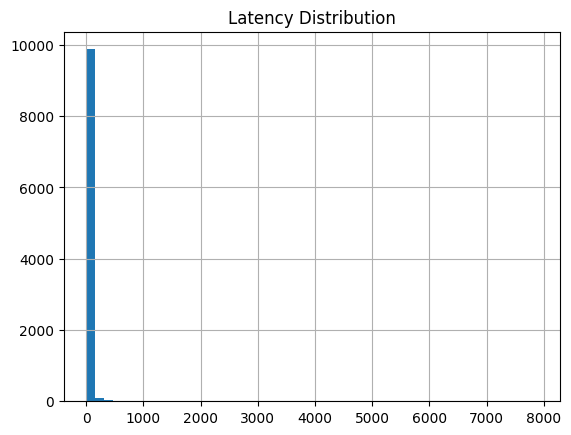

In [6]:
df["avg_latency_ms"].hist(bins=50)
plt.title("Latency Distribution")
plt.show()

In [7]:
df["avg_latency_ms"].quantile([0.5, 0.95, 0.99])
df["total_iops"].quantile([0.5, 0.95, 0.99])

0.50     231.022694
0.95    2026.608172
0.99    3534.145123
Name: total_iops, dtype: float64

In [8]:
df.groupby("device")[["total_iops", "avg_latency_ms", "util_pct"]].mean()

,total_iops,avg_latency_ms,util_pct
device,,,
dm-0,1462.344078,4.153312,70.974817
nvme0n1,231.998858,0.611948,13.398002
nvme1n1,698.156788,0.492560,27.292667
sda,188.768334,1.478398,22.523190
sdb,99.421230,106.740100,32.424689


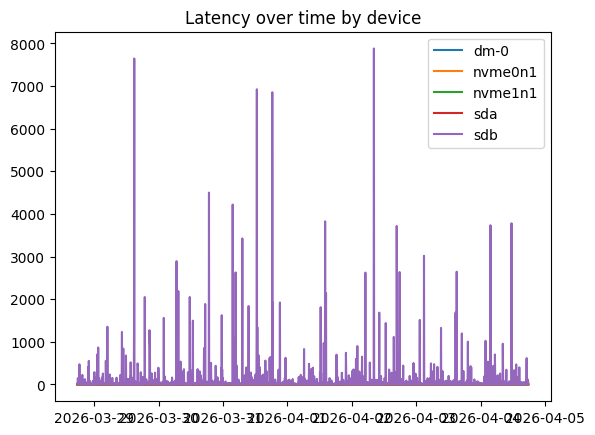

In [9]:
for device in df["device"].unique():
    subset = df[df["device"] == device]
    plt.plot(subset["timestamp"], subset["avg_latency_ms"], label=device)

plt.legend()
plt.title("Latency over time by device")
plt.show()

In [10]:
df[[
    "total_iops",
    "avg_latency_ms",
    "util_pct",
    "aqu_sz",
    "saturation_score"
]].corr()

,total_iops,avg_latency_ms,util_pct,aqu_sz,saturation_score
total_iops,1.000000,-0.053855,0.745521,0.159060,-0.012929
avg_latency_ms,-0.053855,1.000000,0.019066,0.071378,0.993513
util_pct,0.745521,0.019066,1.000000,0.389870,0.089773
aqu_sz,0.159060,0.071378,0.389870,1.000000,0.180160
saturation_score,-0.012929,0.993513,0.089773,0.180160,1.000000


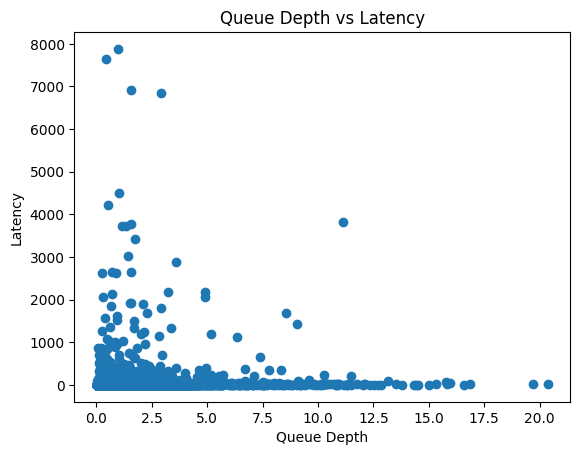

In [11]:
plt.scatter(df["aqu_sz"], df["avg_latency_ms"])
plt.xlabel("Queue Depth")
plt.ylabel("Latency")
plt.title("Queue Depth vs Latency")
plt.show()

In [12]:
df["read_ratio"].describe()
df["write_ratio"].describe()

count    10080.000000
mean         0.459567
std          0.120246
min          0.000000
25%          0.379088
50%          0.450414
75%          0.529327
max          1.000000
Name: write_ratio, dtype: float64

In [13]:
df.groupby("hour_of_day")["total_iops"].mean()

hour_of_day
0     258.789443
1     276.980596
2     279.755218
3     301.925967
4     351.645205
5     392.528502
6     414.490400
7     463.112428
8     551.466836
9     638.237435
10    749.130265
11    813.270423
12    900.951032
13    911.692295
14    886.512709
15    850.699155
16    761.091344
17    650.807806
18    554.839247
19    490.559440
20    405.743325
21    351.551056
22    316.004863
23    295.523599
Name: total_iops, dtype: float64

In [14]:
high_latency = df[df["avg_latency_ms"] > df["avg_latency_ms"].quantile(0.99)]
high_latency.head()

,device,timestamp,r_s,w_s,rmb_s,wmb_s,r_await,w_await,aqu_sz,util_pct,...,avg_latency_ms,read_ratio,write_ratio,avg_request_size_kb,saturation_score,io_intensity,latency_pressure,hour_of_day,day_of_week,workload_pattern
8073,sdb,2026-03-28 18:31:36.173899+00:00,23.419022,31.750353,1.792474,2.437201,1.288366,822.748666,0.175022,16.916972,...,474.044391,0.424493,0.575507,78.507105,961.797923,233.348569,557.012494,18,5,balanced
8112,sdb,2026-03-28 21:46:38.801807+00:00,12.444281,23.142724,1.268867,1.134309,1.765422,628.982140,0.306482,11.393454,...,409.653171,0.349686,0.650314,69.150296,834.197538,85.521826,535.204615,21,5,balanced
8115,sdb,2026-03-28 22:00:42.880861+00:00,6.461359,17.504337,0.991057,1.388589,19.064253,750.612764,0.407011,10.994526,...,553.380966,0.269609,0.730391,101.676881,1124.469515,57.029864,778.612933,22,5,write_heavy
8153,sdb,2026-03-29 01:11:21.032638+00:00,10.785048,12.920303,0.761800,1.543553,0.194893,1297.058711,1.026969,11.808616,...,707.034172,0.454963,0.545037,99.584350,1450.781709,54.649216,1433.136073,1,6,latency_sensitive
8157,sdb,2026-03-29 01:30:46.146387+00:00,8.551499,17.144994,1.262879,1.177014,8.351677,1296.729674,0.093135,7.648910,...,867.972226,0.332789,0.667211,97.229241,1742.562947,62.696694,948.810574,1,6,balanced


In [15]:
df.sort_values("saturation_score", ascending=False).head(10)

,device,timestamp,r_s,w_s,rmb_s,wmb_s,r_await,w_await,aqu_sz,util_pct,...,avg_latency_ms,read_ratio,write_ratio,avg_request_size_kb,saturation_score,io_intensity,latency_pressure,hour_of_day,day_of_week,workload_pattern
9389,sdb,2026-04-02 08:11:18.040200+00:00,64.506839,62.582576,3.727210,7.857439,0.605826,16004.334241,0.999883,73.016621,...,7881.313643,0.507571,0.492429,93.341221,15829.132076,1472.286342,15761.702586,8,3,balanced
8318,sdb,2026-03-29 14:56:31.278252+00:00,12.664309,45.361478,3.493612,4.095604,4.260578,9779.153207,0.453646,16.224554,...,7645.752367,0.218253,0.781747,133.929387,15313.226402,440.370278,11114.220308,14,6,write_heavy
8866,sdb,2026-03-31 12:35:58.146877+00:00,29.822646,142.521182,6.280839,14.046892,0.718103,8373.366486,1.553498,82.807141,...,6924.550303,0.173042,0.826958,120.779475,13937.109108,3503.359052,17681.823480,12,1,latency_sensitive
8935,sdb,2026-03-31 18:20:55.678697+00:00,39.529981,105.846477,8.732704,6.994062,0.061189,9414.902336,2.941818,38.345912,...,6854.869582,0.271915,0.728085,110.775905,13817.166670,2286.301584,27020.650401,18,1,latency_sensitive
8652,sdb,2026-03-30 18:46:07.675821+00:00,79.076778,36.609471,3.048739,8.552810,29.451897,14156.659431,1.015155,41.046280,...,4500.074756,0.683545,0.316455,102.691425,9051.127292,1342.139639,9068.346481,18,0,latency_sensitive
8758,sdb,2026-03-31 03:35:40.265860+00:00,20.874209,40.111414,1.786578,2.859723,0.175151,6414.501923,0.533634,17.663453,...,4219.000875,0.342281,0.657719,78.015309,8462.842484,283.357559,6470.401322,3,1,balanced
9171,sdb,2026-04-01 14:01:39.668017+00:00,82.453346,183.164951,5.071876,8.341482,3.796863,5547.180080,11.120958,65.150318,...,3826.400670,0.310420,0.689580,51.710591,8019.005243,3562.833482,46379.642276,14,2,saturated
10004,sdb,2026-04-04 11:26:24.690570+00:00,30.377702,31.367300,2.195111,5.332734,2.877709,7440.199250,1.548457,32.004221,...,3781.138095,0.491986,0.508014,124.844329,7624.732005,464.806806,9636.067240,11,5,latency_sensitive
9910,sdb,2026-04-04 03:36:10.754284+00:00,9.174402,15.678810,0.521260,0.905563,0.904006,5919.056823,1.180719,11.335964,...,3734.409144,0.369144,0.630856,58.787861,7509.907838,35.461144,8143.696831,3,5,latency_sensitive
9491,sdb,2026-04-02 16:40:52.305869+00:00,38.423777,69.748548,5.885092,10.176353,0.179071,5766.382599,1.343129,50.573785,...,3718.175541,0.355209,0.644791,152.043695,7501.931853,1737.403884,8712.165987,16,3,latency_sensitive
